In [1]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.decomposition import FastICA

from utils import load_images
import joblib
import pathlib
from pathlib import Path

from insilico_stimuli.stimuli import GaborSet, CenterSurround

import pymc as pm
import pytensor.tensor as pt

seed = 42
rng = np.random.default_rng(seed)

WARNING (pytensor.tensor.blas): Using NumPy C-API based implementation for BLAS functions.


In [2]:
data_basepath = Path("/src/project/data/ica/repeat_9_crop_12_comp_40")
layer3_model_path = data_basepath / "layer3_models/layer3_340.joblib"
layer2_models_path = data_basepath / "layer2_models"

layer3_model = joblib.load(layer3_model_path)
print("layer3_model", layer3_model)
print("layer3 n_components", layer3_model.n_components)
layer3_model_mixing = layer3_model.mixing_

layer2_model_list = []
print("Loading layer 2 models")
for entry in layer2_models_path.iterdir():
    # go through files and load joblib files
    if entry.is_file() and entry.suffix == ".joblib":
        model = joblib.load(entry)
        layer2_model_list.append(model)
        print(model)

n_patch_components = model.components_.shape[0]
print("n_components", n_patch_components)
n_patch_pixels = model.components_.shape[1]
print("n_patch_pixels", n_patch_pixels)


layer3_model FastICA(n_components=340, random_state=42, whiten='unit-variance')
layer3 n_components 340
Loading layer 2 models
FastICA(n_components=40, random_state=752767290, whiten='unit-variance')
FastICA(n_components=40, random_state=3653403230, whiten='unit-variance')
FastICA(n_components=40, random_state=70985653, whiten='unit-variance')
FastICA(n_components=40, random_state=323153948, whiten='unit-variance')
FastICA(n_components=40, random_state=1322117303, whiten='unit-variance')
FastICA(n_components=40, random_state=2195314464, whiten='unit-variance')
FastICA(n_components=40, random_state=2735729614, whiten='unit-variance')
FastICA(n_components=40, random_state=175979944, whiten='unit-variance')
FastICA(n_components=40, random_state=1158725111, whiten='unit-variance')
n_components 40
n_patch_pixels 144


In [3]:
layer3_model_mixing.shape

(360, 340)

In [4]:
A_plus = []
for layer2_model in layer2_model_list:
    A_plus.append(layer2_model.mixing_)
A_plus = np.array(A_plus)
print("A_plus shape", A_plus.shape)

A_plus shape (9, 144, 40)


In [5]:
A_star = np.zeros((n_patch_pixels * 9, n_patch_components * 9))
for idx, A in enumerate(A_plus):
    A_star[
        idx * n_patch_pixels: (idx + 1) * n_patch_pixels,
        idx * n_patch_components: (idx + 1) * n_patch_components,
    ] = A
print("A_star shape", A_star.shape)

A_star shape (1296, 360)


In [6]:
one_hot_layer3 = np.zeros(layer3_model.n_components)
one_hot_layer3[0] = 100
one_hot_layer3 = one_hot_layer3.reshape(-1, 1)
print(one_hot_layer3.shape)

(340, 1)


In [7]:
layer3_model_mixing.shape[0]

360

In [8]:
(layer3_model_mixing @ one_hot_layer3).shape

(360, 1)

In [9]:
model = pm.Model()
with model:
    observed_image = pm.MutableData("observed_image", np.zeros((A_star.shape[0], 1)))
    G = pm.Laplace("G", mu=0, b=1, shape=(layer3_model.n_components, 1))
    # G = pm.Deterministic("G", pt.as_tensor_variable(one_hot_layer3))
    X_mu = pm.Deterministic("X_mu", layer3_model_mixing @ G)
    X_sigma = pm.Deterministic("X_sigma", pt.as_tensor_variable([0.1]))
    X = pm.Normal("X", mu=X_mu, sigma=X_sigma, shape=(layer3_model_mixing.shape[0], 1))
    I_mu = pm.Deterministic("I_mu", A_star @ X)
    I_sigma = pm.Deterministic("I_sigma", pt.as_tensor_variable([0.1]))
    I = pm.Normal("I", mu=I_mu, sigma=I_sigma, shape=(A_star.shape[0], 1), observed=observed_image)

In [10]:
n_samples = 100
with model:
    idata = pm.sample_prior_predictive(n_samples, random_seed=seed, return_inferencedata=False)

Sampling: [G, I, X]


In [11]:
idata.keys()

dict_keys(['G', 'X_mu', 'X_sigma', 'I_mu', 'I_sigma', 'I', 'X'])

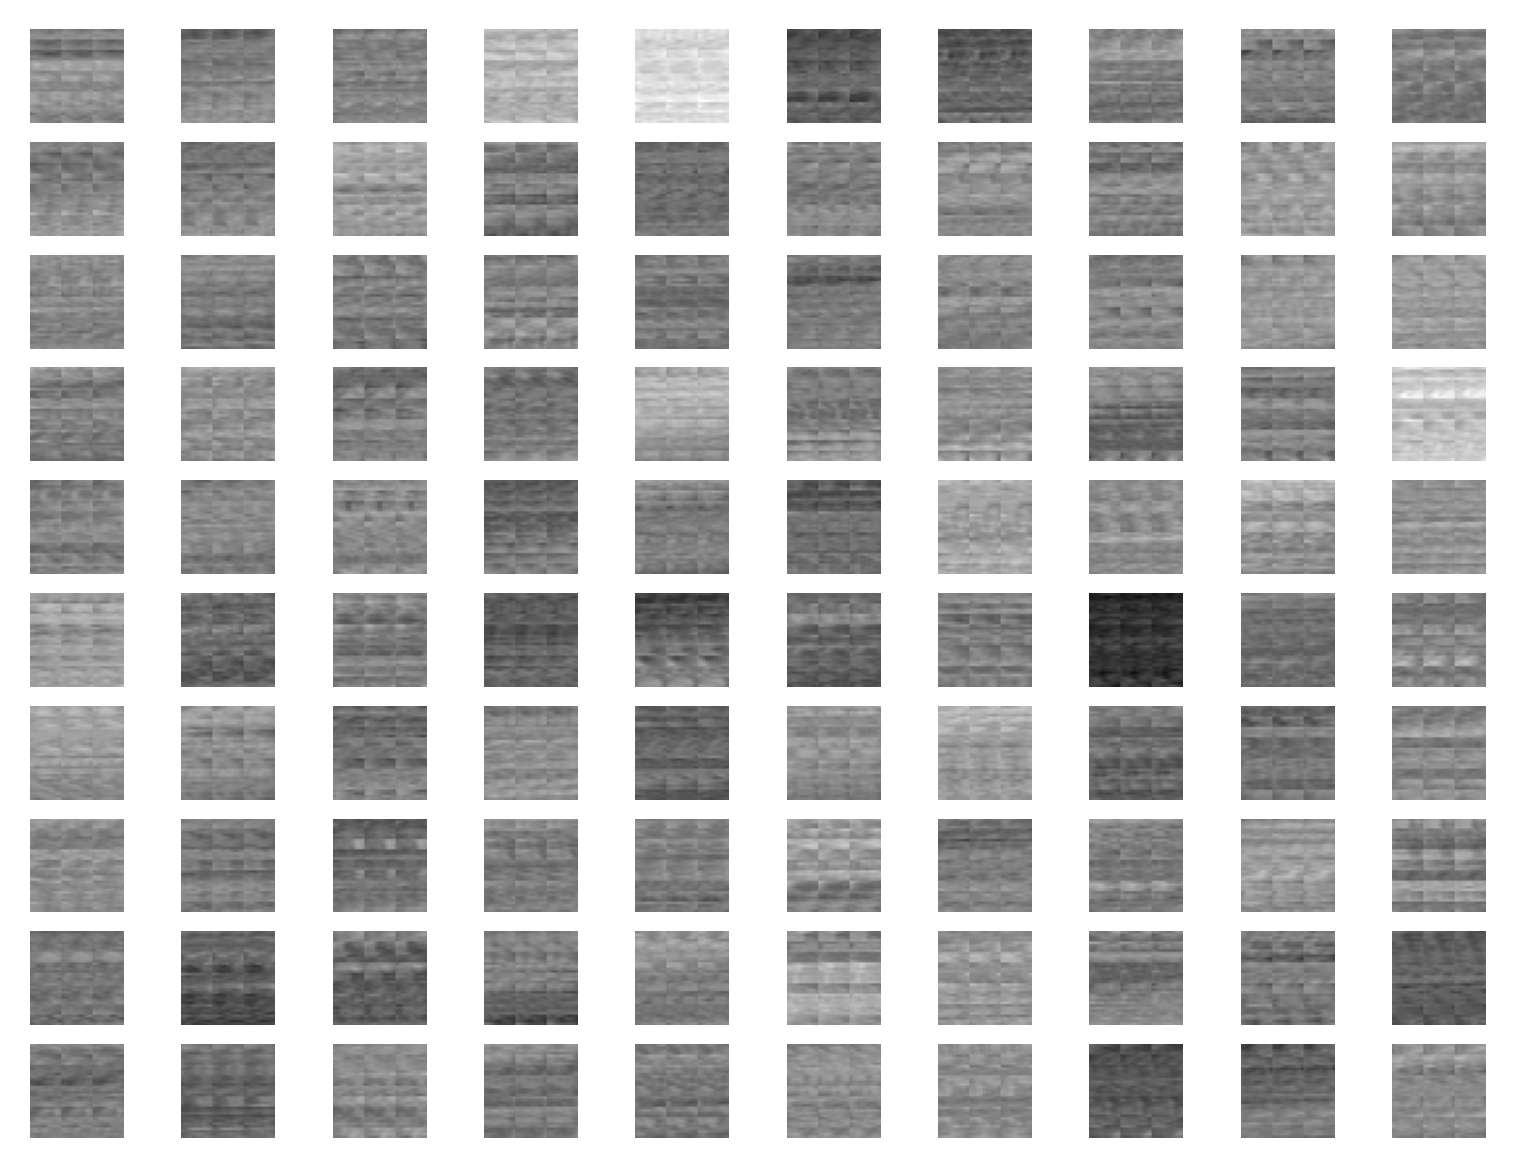

In [12]:
fig, axs = plt.subplots(10, 10, dpi=300)
for idx, ax in enumerate(axs.flatten()):
    ax.imshow(idata['I_mu'][idx].squeeze(-1).reshape(36, 36), cmap='gray', vmin=-np.abs(idata['I_mu']).max(), vmax=np.abs(idata['I_mu']).max())
    ax.axis('off')

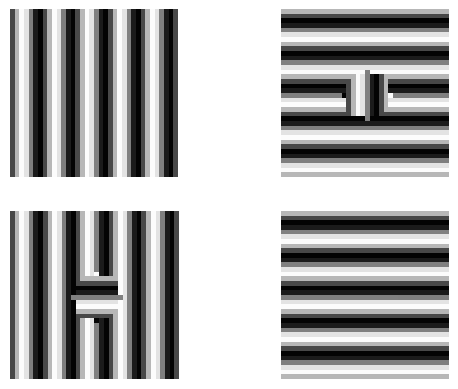

In [13]:
center_surround_params = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/7],
    "spatial_frequencies_surround": [1/7],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [0, np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_surround_gabors = CenterSurround(**center_surround_params)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors.images().shape[0]:
        ax.imshow(center_surround_gabors.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

In [14]:
excitatory_1 = center_surround_gabors.images()[0].flatten()
excitatory_2 = center_surround_gabors.images()[3].flatten()
inhibitory_1 = center_surround_gabors.images()[1].flatten()
inhibitory_2 = center_surround_gabors.images()[2].flatten()

In [15]:
excitatory_1.reshape(-1, 1).shape

(1296, 1)

In [16]:
draws = 1000
tune = 1000
chains = 1
with model:
    pm.set_data({"observed_image": excitatory_1.reshape(-1, 1)})
    idata_cpu = pm.sample(
        draws=draws,
        tune=tune,
        chains=chains,
        cores=4,
        random_seed=seed,
        # return_inferencedata=False,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [G, X]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 163 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


In [17]:
# import pymc.sampling_jax as pmj

# draws = 1000
# tune = 1000
# chains = 1
# # cores = 4
# return_inferencedata = True
# with model:
#     pm.set_data({"observed_image": excitatory_1.reshape(-1, 1)})
#     trace_jax = pmj.sample_numpyro_nuts(
#         draws=draws,
#         tune=tune,
#         chains=chains,
#         random_seed=seed,
#         # return_inferencedata=return_inferencedata,
#     )

In [18]:
G_samples = np.array(idata_cpu['posterior']['G'])

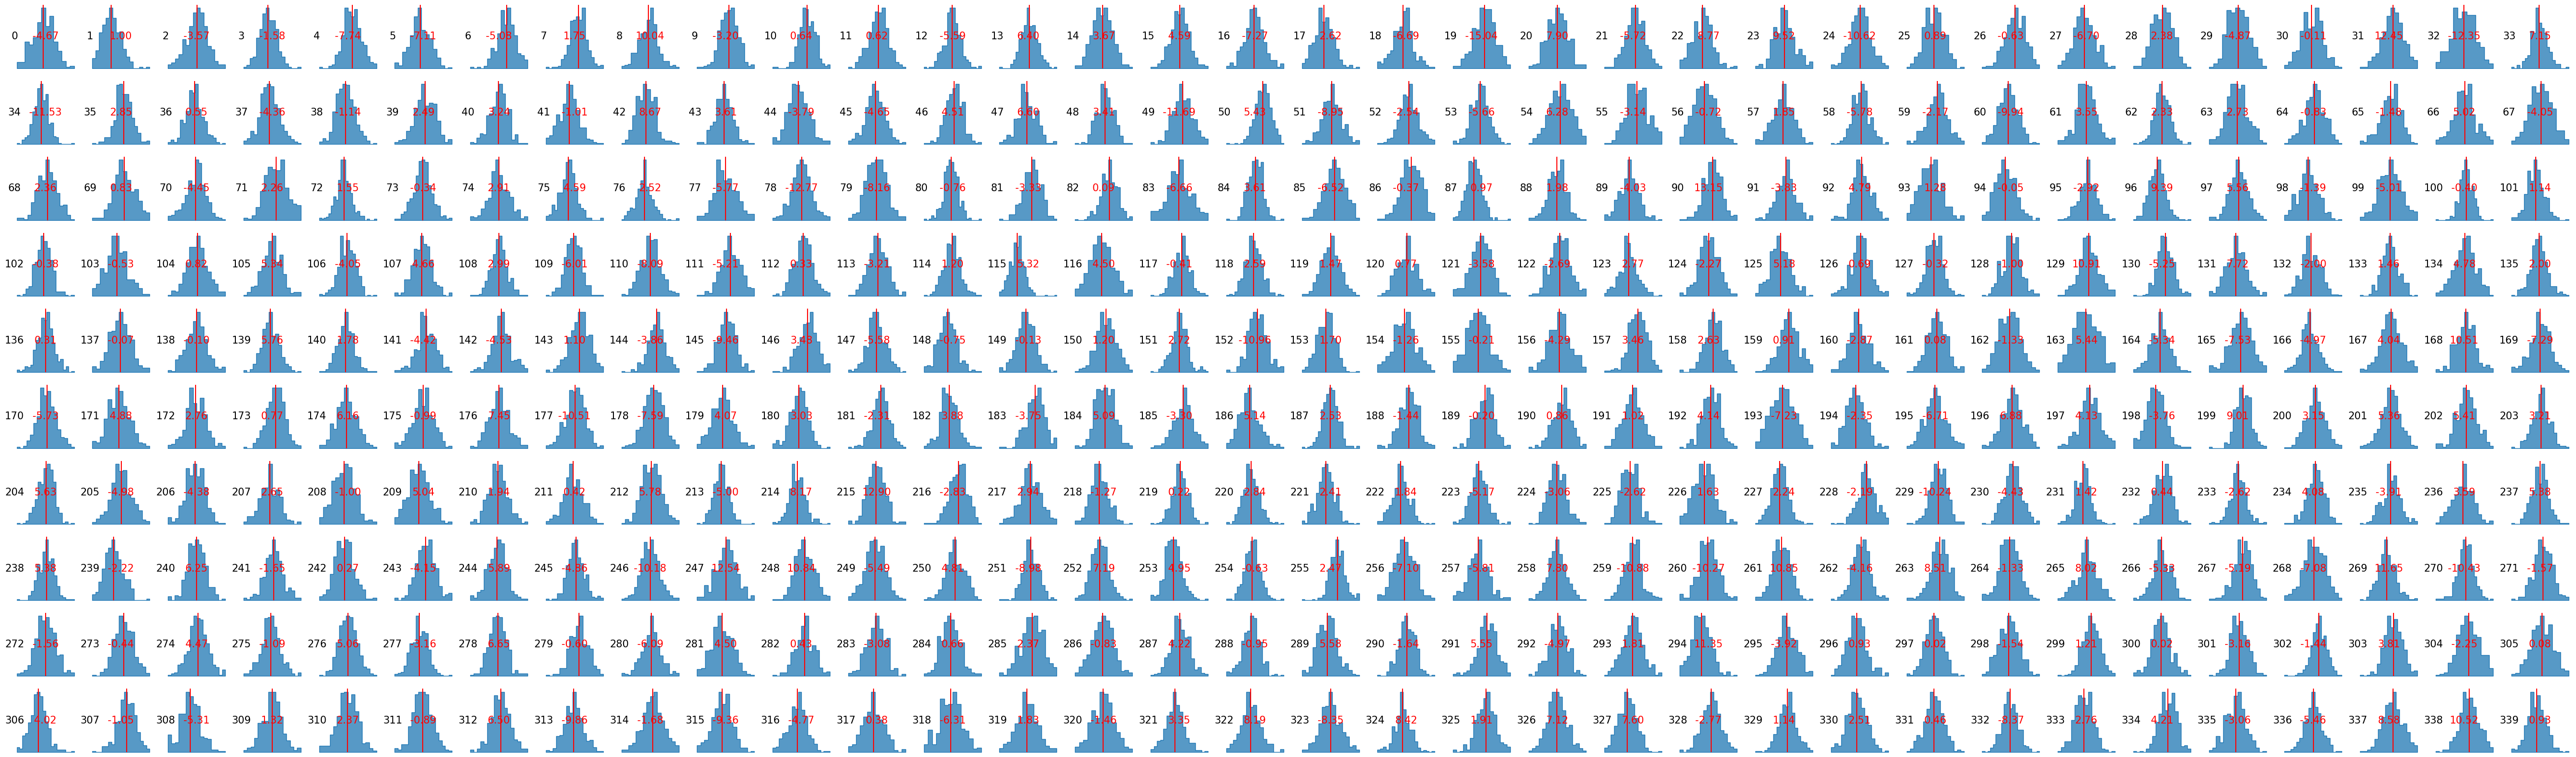

In [21]:
fig, axs = plt.subplots(10, 34, figsize=(34*2, 10*2))
for idx, ax in enumerate(axs.flatten()):
    sns.histplot(G_samples[:, idx].ravel(), element="step", ax=ax)
    ax.text(0.01, 0.5, f"{idx}", size=15, ha="center", va="center", transform=ax.transAxes)
    mean = G_samples[:, idx].mean()
    ax.axvline(mean, color='red')
    ax.text(0.5, 0.5, f"{mean*1000:.2f}", size=15, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.axis("off")

In [22]:
draws = 1000
tune = 1000
chains = 1
with model:
    pm.set_data({"observed_image": excitatory_2.reshape(-1, 1)})
    idata_cpu_2 = pm.sample(
        draws=draws,
        tune=tune,
        chains=chains,
        cores=4,
        random_seed=seed,
        # return_inferencedata=False,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [G, X]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 157 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


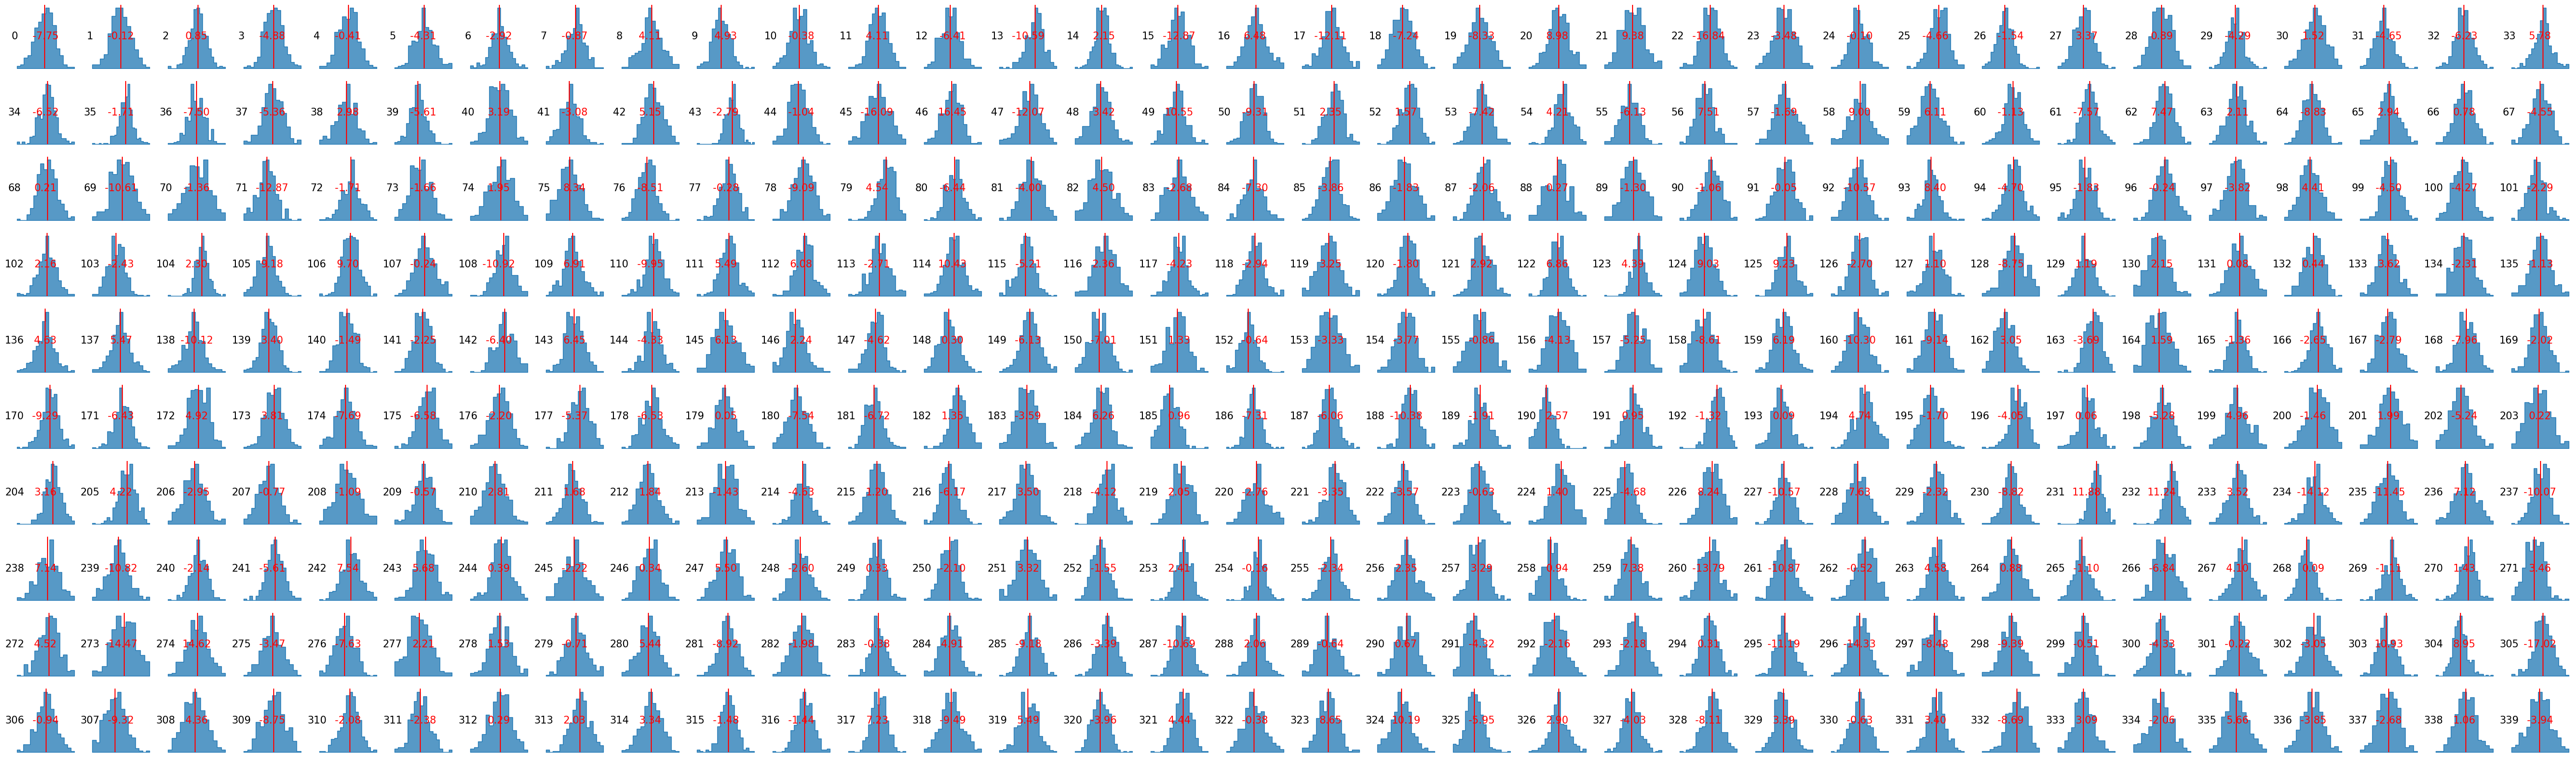

In [24]:
G_samples_2 = np.array(idata_cpu_2['posterior']['G'])
fig, axs = plt.subplots(10, 34, figsize=(34*2, 10*2))
for idx, ax in enumerate(axs.flatten()):
    sns.histplot(G_samples_2[:, idx].ravel(), element="step", ax=ax)
    ax.text(0.01, 0.5, f"{idx}", size=15, ha="center", va="center", transform=ax.transAxes)
    mean = G_samples_2[:, idx].mean()
    ax.axvline(mean, color='red')
    ax.text(0.5, 0.5, f"{mean*1000:.2f}", size=15, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.axis("off")

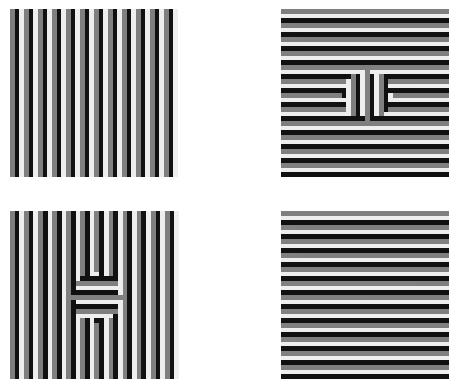

In [27]:
center_surround_params = {
    "canvas_size": [36, 36],
    "spatial_frequencies_center": [1/3],
    "spatial_frequencies_surround": [1/3],
    "phases_center": [np.pi/2],
    "phases_surround": [np.pi/2],
    "grey_levels": [0.0],
    "orientations_center": [0, np.pi/2],
    "orientations_surround": [0., np.pi/2],
    "locations": [[18, 18]],
    "sizes_total": [36],
    "sizes_center": [20/4/36],
    "sizes_surround": [20/4/36],
    "contrasts_center": [1.0],
    "contrasts_surround": [1.0],
}

center_surround_gabors = CenterSurround(**center_surround_params)
fig, axs = plt.subplots(2, 2, dpi=100)
for i, ax in enumerate(axs.flatten()):
    if i < center_surround_gabors.images().shape[0]:
        ax.imshow(center_surround_gabors.images()[i], cmap="gray", vmin=-1, vmax=1)
        # write the label on the left side of the subplot
        # ax.text(-0.3, 0.5, f"{i}", size=5, ha="center", va="center", transform=ax.transAxes)
    ax.axis("off")

In [29]:
excitatory_1 = center_surround_gabors.images()[0].flatten()
excitatory_2 = center_surround_gabors.images()[3].flatten()
inhibitory_1 = center_surround_gabors.images()[1].flatten()
inhibitory_2 = center_surround_gabors.images()[2].flatten()

draws = 1000
tune = 1000
chains = 1
with model:
    pm.set_data({"observed_image": excitatory_1.reshape(-1, 1)})
    idata_cpu = pm.sample(
        draws=draws,
        tune=tune,
        chains=chains,
        cores=4,
        random_seed=seed,
        # return_inferencedata=False,
    )

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [G, X]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 168 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


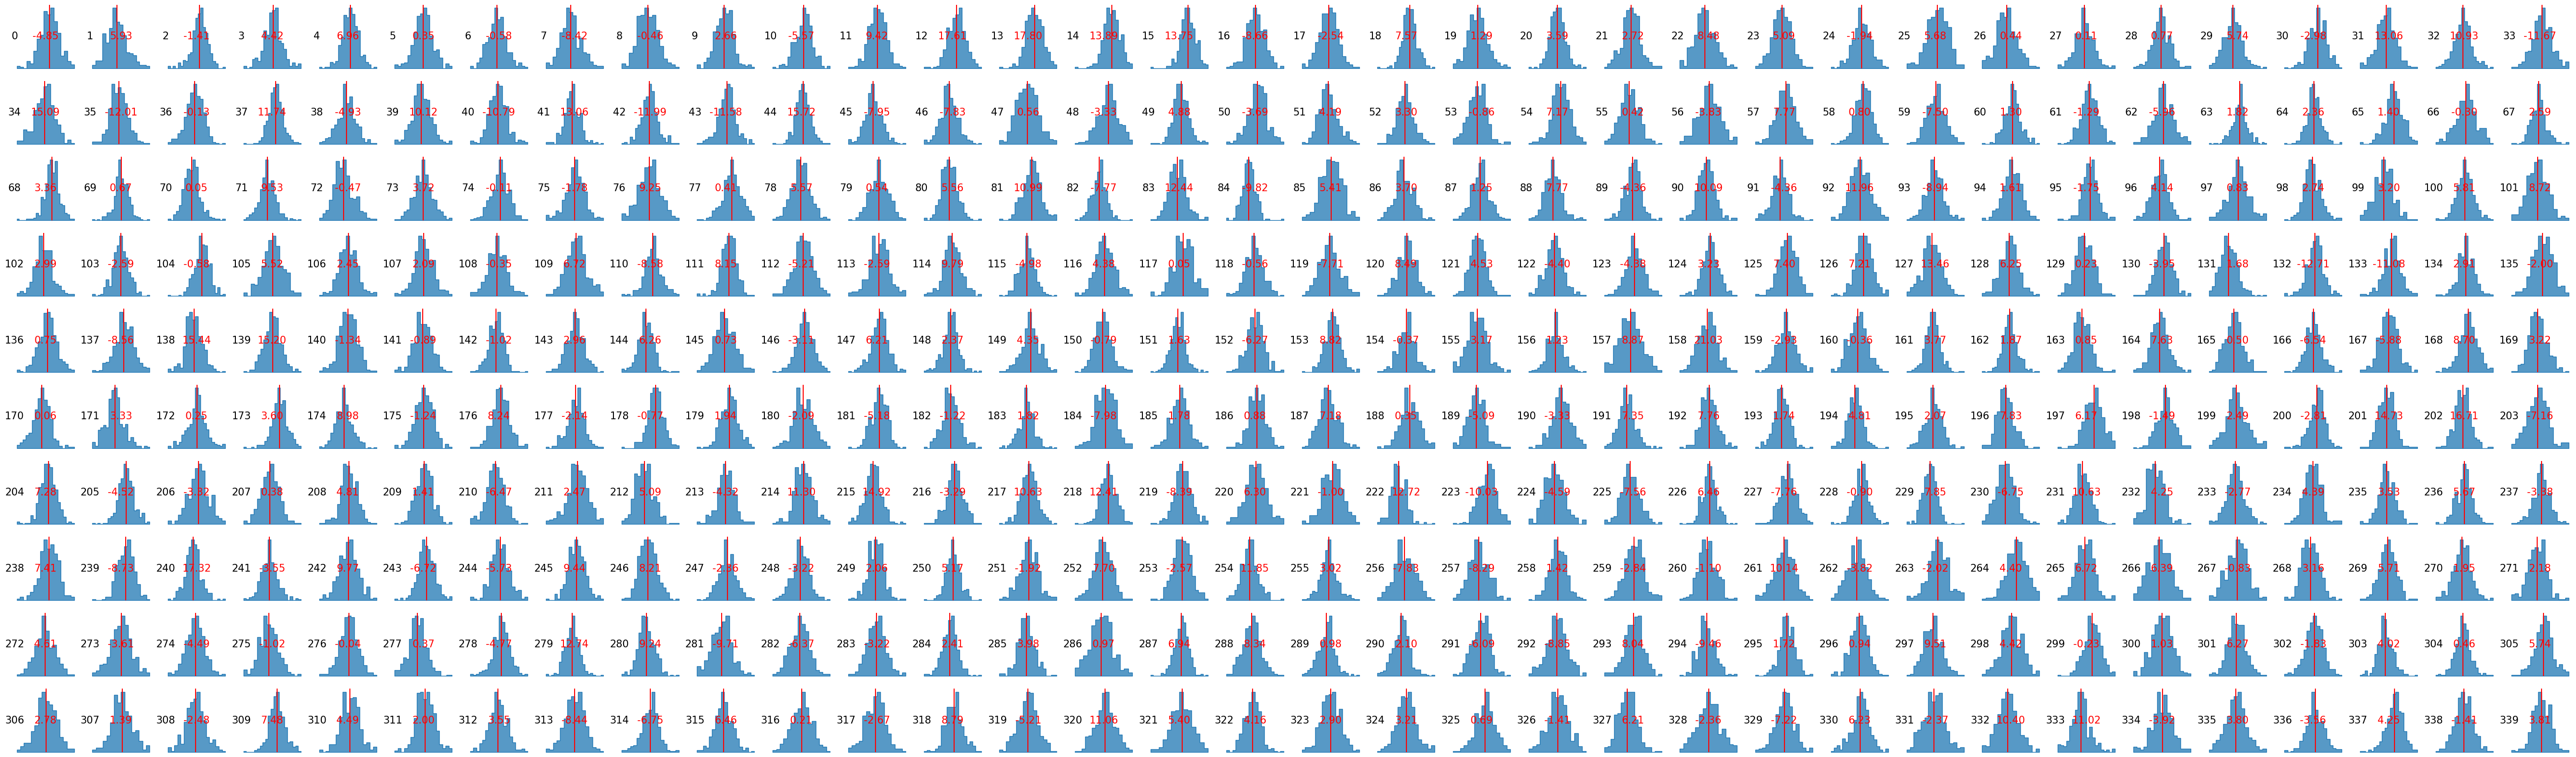

In [30]:
G_samples = np.array(idata_cpu['posterior']['G'])
fig, axs = plt.subplots(10, 34, figsize=(34*2, 10*2))
for idx, ax in enumerate(axs.flatten()):
    sns.histplot(G_samples[:, idx].ravel(), element="step", ax=ax)
    ax.text(0.01, 0.5, f"{idx}", size=15, ha="center", va="center", transform=ax.transAxes)
    mean = G_samples[:, idx].mean()
    ax.axvline(mean, color='red')
    ax.text(0.5, 0.5, f"{mean*1000:.2f}", size=15, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.axis("off")

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (1 chains in 1 job)
NUTS: [G, X]


Sampling 1 chain for 1_000 tune and 1_000 draw iterations (1_000 + 1_000 draws total) took 171 seconds.
Only one chain was sampled, this makes it impossible to run some convergence checks


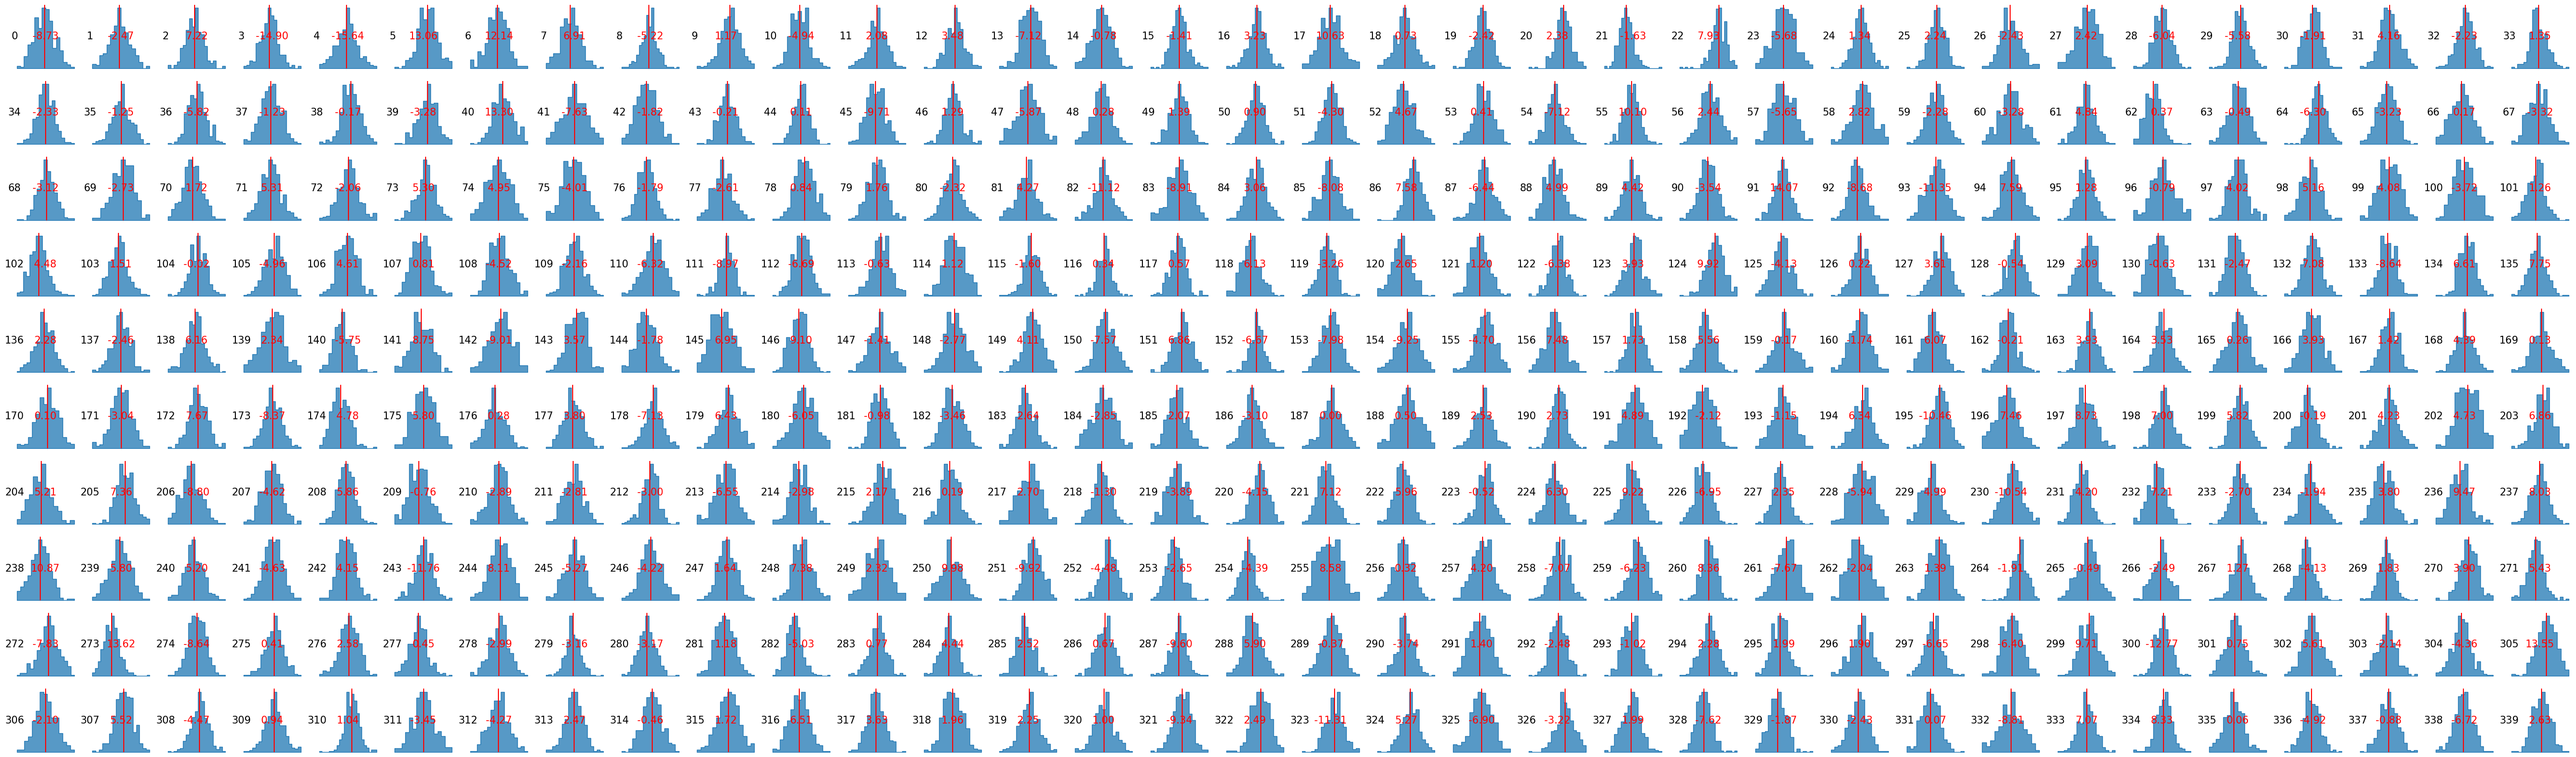

In [31]:
draws = 1000
tune = 1000
chains = 1
with model:
    pm.set_data({"observed_image": excitatory_2.reshape(-1, 1)})
    idata_cpu_2 = pm.sample(
        draws=draws,
        tune=tune,
        chains=chains,
        cores=4,
        random_seed=seed,
        # return_inferencedata=False,
    )

G_samples_2 = np.array(idata_cpu_2['posterior']['G'])
fig, axs = plt.subplots(10, 34, figsize=(34*2, 10*2))
for idx, ax in enumerate(axs.flatten()):
    sns.histplot(G_samples_2[:, idx].ravel(), element="step", ax=ax)
    ax.text(0.01, 0.5, f"{idx}", size=15, ha="center", va="center", transform=ax.transAxes)
    mean = G_samples_2[:, idx].mean()
    ax.axvline(mean, color='red')
    ax.text(0.5, 0.5, f"{mean*1000:.2f}", size=15, ha="center", va="center", transform=ax.transAxes, color='red')
    ax.axis("off")